# Evaluering av modellar

Modellar i statistikk og maskinlæring er tilfeldige konstruksjonar,
dvs. dei er like tilfeldige som datasettet som ligg til grunn.
Om me gjer nye observasjonar, vil dei se annleis ut, og me får ein
annan modell.

Dette ser me tydleg i meiningsmålingar.
Ofte er der fleire byrå ute og gjer meiningsmålingar på same tid,
og dei bruker dei same statistiske metodane.
Likevel får dei forskjellige resultat, og
dei treff sjelden valresultatet presist.

Regresjonsmodellen som me fann i 
[forrige øving](Linear%20Regression%20in%20SciKitLearn)
gjev ei optimal skildring av datasettet som det er trent på.
Det som er interessant er derimot kor godt det skildrar resten
av populasjonen og kor godt det kan predikera nye og hittil ukjende
data.  Det finn me berre ut ved å testa.  På uavhengige data.

Her skal me gå gjennom eit enkelt og standardisert testlaup,
der me evaluerer modellen som me fann i den førre øvinga.

## Datasettet

Lat oss fyrst lasta datasettet på same måte som sist.  Me 
importerer òg dei same biblioteka som me brukte sist.

In [1]:
from sklearn.datasets import load_diabetes
from sklearn import linear_model
import matplotlib.pyplot as plt
import numpy as np

diabetes = load_diabetes()
x = diabetes.data[:,2:3]
y = diabetes.target
print(x)
print(y)

[[ 0.06169621]
 [-0.05147406]
 [ 0.04445121]
 [-0.01159501]
 [-0.03638469]
 [-0.04069594]
 [-0.04716281]
 [-0.00189471]
 [ 0.06169621]
 [ 0.03906215]
 [-0.08380842]
 [ 0.01750591]
 [-0.02884001]
 [-0.00189471]
 [-0.02560657]
 [-0.01806189]
 [ 0.04229559]
 [ 0.01211685]
 [-0.0105172 ]
 [-0.01806189]
 [-0.05686312]
 [-0.02237314]
 [-0.00405033]
 [ 0.06061839]
 [ 0.03582872]
 [-0.01267283]
 [-0.07734155]
 [ 0.05954058]
 [-0.02129532]
 [-0.00620595]
 [ 0.04445121]
 [-0.06548562]
 [ 0.12528712]
 [-0.05039625]
 [-0.06332999]
 [-0.03099563]
 [ 0.02289497]
 [ 0.01103904]
 [ 0.07139652]
 [ 0.01427248]
 [-0.00836158]
 [-0.06764124]
 [-0.0105172 ]
 [-0.02345095]
 [ 0.06816308]
 [-0.03530688]
 [-0.01159501]
 [-0.0730303 ]
 [-0.04177375]
 [ 0.01427248]
 [-0.00728377]
 [ 0.0164281 ]
 [-0.00943939]
 [-0.01590626]
 [ 0.0250506 ]
 [-0.04931844]
 [ 0.04121778]
 [-0.06332999]
 [-0.06440781]
 [-0.02560657]
 [-0.00405033]
 [ 0.00457217]
 [-0.00728377]
 [-0.0374625 ]
 [-0.02560657]
 [-0.02452876]
 [-0.01806

Me har ikkje fleire data enn det eine settet.  For å kunne evaluera
modellen må me difor halda tilbake ein del av datasettet til å testa
på.  Dette testsettet kan me ikkje bruka i treninga.
Ein vanleg tommelfingerregel er å bruka 20% av datasettet til testing
og 80% til trening.

::: {admonition} Merknad
Dette er ein tommelfingerregel.
Dersom du er kjend med estimering og hypotesetesting frå statistikk, 
so kan du kanskje rekna ut kor
mange datapunkt du treng i testsettet for å få eit statistisk
signifikant resultat. Det er naudsynt for å kunna vita kor mykje
me kan stola på modellen, men her skal me nøya oss med tommelfingerregelen.
:::

::: {admonition} Merknad
Der større testsett gjev ein meir påliteleg evaluering, vil større 
treningssett gje ein betre modell.  Det er eit dilemma.
:::

Me hadde 242 objekt i datasettet.  Eit testsett på 20% vert då
om lag 49 objekt, med 193 til treningssettet.

In [2]:
trainx = x[:193]
trainy = y[:193]
testx = x[193:]
testy = y[193:]

## Trening av diskriminanten

Me kan trena modellen som før.

In [12]:
reg = linear_model.LinearRegression()
reg.fit(trainx,trainy)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


::: {admonition} Oppgåve
Visualiser treningssettet og prediksjonsmodellen (regresjonslinen).
Vert det svært forskjellig frå visualiseringa i forrige oppgåve,
då du trente på heile datasettet?
:::

Me kan òg sjekka nøyaktig kor mykje feil modellen gjer på treningssettet.

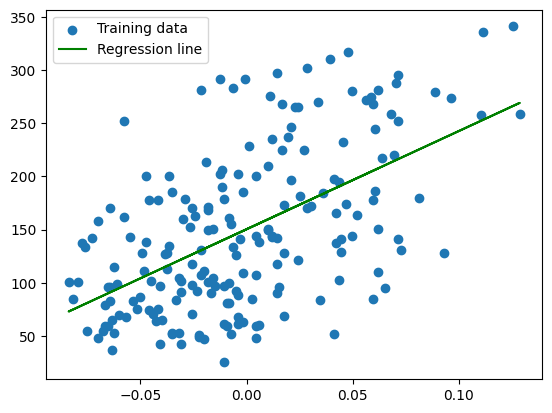

In [13]:
# Oppgave Visualiser treningssettet og prediksjonsmodellen (regresjonslinen).
trainPred = reg.predict(trainx)

plt.figure()
plt.scatter(trainx, trainy, label = "Training data")
plt.plot(trainx, trainPred, c = "green", label = "Regression line")
plt.legend()
plt.show()


In [4]:
pred = reg.predict( trainx )
error = pred - trainy
print( error )

[  56.34290926   27.79078552   50.41115707  -66.36703754  -18.26893131
   15.74813064  -31.22627643   85.59457307   97.34290926 -123.56751548
  -28.08124983   97.51779428  -55.29878973  -36.40542693    8.68841381
  -37.34144461   23.41968805   17.53912172   43.62869697  -34.34144461
   29.81211296   80.67561734   78.60310404  -38.65282525   -0.55471902
  -63.36277205  -58.10684276  120.35144024   -0.32864815 -138.38836498
   62.41115707   30.84623687  -74.90875454   16.78652003   26.83770589
   19.70974125  -93.50353316 -115.45661279  -35.69548013   73.53059074
   42.62016599   32.85476784   79.62869697   36.67988283  -45.68268366
   64.7268032   -50.36703754  -59.12390472   36.75239613   21.53059074
  -11.38409949  -59.47794023   82.62443148   31.65002441   -8.51206414
  -23.21774546  136.42395354   54.83770589  -79.15802862  -43.31158619
   85.60310404   10.56898014   91.61590051  -12.26466582   55.68841381
  -35.31585168  -16.34144461   39.64575892  -37.29452424  -70.23054192
   37.

Legg merke til at me kan køyra prediksjonen på heile datasettet i eitt kall.

::: {admonition} Refleksjon
Kva skjer her?  Kva representerer `error`?  Kva verdi svarer til feil og kva til
rett prediksjon?
:::

Me kan plotta eit histogram over alle `error`-verdiane.

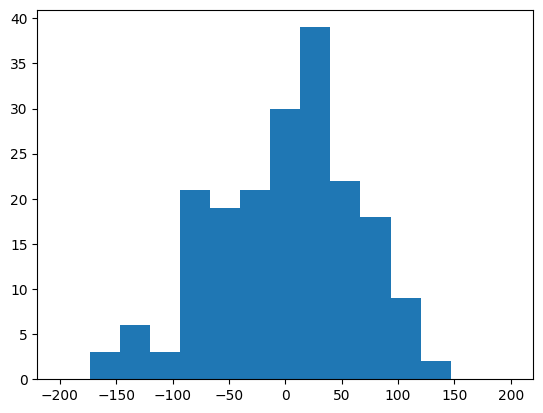

In [5]:
plt.hist(error, bins=15, range=[-200, 200])
plt.show()

::: {admonition} Refleksjon
Kva fortel histogrammet oss?
:::

Objektet `error` er ein `numpy` *array*, med alle dei metodane som 
`numpy` gjev oss.  Det er dermed enkelt å finna gjennomsnittleg feil.

In [6]:
print( "Gjennomsnittsfeil:", error.mean() )
print( "Minimum:", error.min() )
print( "Maksimum:", error.max() )

Gjennomsnittsfeil: 4.1233568085560215e-15
Minimum: -155.18362154971436
Maksimum: 136.42395353915396


::: {admonition} Refleksjon
Kvifor er gjennomsnittsfeilen so liten, altso null i femten desimalar?
:::

Me kan finna gjennomsnittleg absoluttfeil òg, altso feil utan forteikn.

In [7]:
print( "Gjennomsnitleg absoluttfeil:", abs(error).mean() )

Gjennomsnitleg absoluttfeil: 51.42229996337279


::: {admonition} Refleksjon
Er dette gjennomsnittet konsistent med det som du ser i histogrammet?
:::

## Testing

Me kan gjera akkurat den same testen med testsettet,
som med treningssettet.

In [8]:
testpred = reg.predict( testx )
testerror = testpred - testy
print( testerror )

[  29.60736953    9.82064394   51.48793586   35.76945808   24.57324562
   58.37276768   18.76519259  -61.18362155   59.80784747  -44.4182234
  -43.53339158 -120.43955084   94.4026261   -21.51632963   -9.59310841
   32.42821903   56.65855539  -27.46940926  114.44101549   80.57324562
   35.86756431   54.71827222  -25.78505538  -64.55471902 -116.53765707
 -124.15376313  -73.24760387   35.74386515   21.73959966 -125.31158619
  -21.32011717   11.85050236  -27.54192256   30.76945808   14.70547576
  -21.36277205   82.65002441   -3.69548013  -32.29025875 -108.41395791
   94.44101549  -59.56751548   12.64575892   89.56044916   14.85903333
 -115.37556852  -93.4907367   -55.70827659  -34.37983401   57.67988283
   60.76945808   13.37276768   -7.2731968    42.71400673   23.91021919
  -63.60163939   -8.65282525 -100.6357633    -1.80211733  114.35144024
   31.45381196 -107.6357633   -63.15376313  -47.04951565   35.80784747
   38.68414832   66.73106869  103.62016599    8.75239613  -39.91728551
  -37.1

::: {admonition} Oppgåve
Lag eit histogram av `testerror`.

Kan du visa feila på test- og treningsettet i same figur?
:::

::: {admonition} Refleksjon
Samanlikna feila på test- og treningssettet?
Gjer denne modellen det like godt på det nye testsettet som det
gjorde på treningssettet?
:::

## Oppsummering

Læringsmålet i denne øvinga var å sjå korleis syntaksen
i python kan sjå ut når me skal testa ein regresjonsmodell 
i python.

Denne testinga er uhyre viktig.
Det skjer ofte at ein modell fungerer godt på treningssettet og
dårleg på testsettet.

Difor skal de ta med dykk desse teknikkane og prøva dei ut på større
og meir interessante datasett.

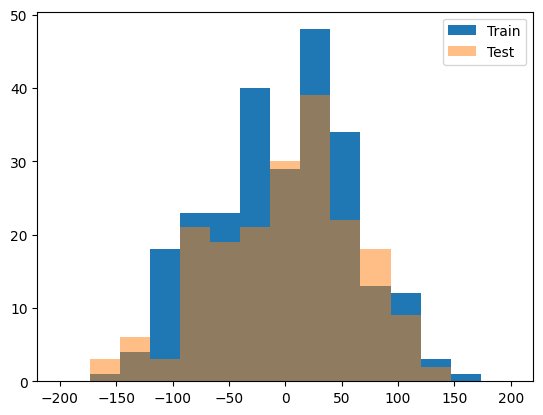

In [18]:
#Oppgåve Lag eit histogram av `testerror`.

plt.figure()
plt.hist(testerror, bins = 15, range =[-200, 200], label = "Train")
plt.hist(error, bins = 15, range=[-200, 200], alpha=0.5, label = "Test")
plt.legend()
plt.show()